# 06 — Système temps réel, soft sensor qualité et rapport final

Ce dernier notebook boucle la spécification :
1. Entraîne le **soft sensor qualité** (GRU multi-sorties) — Objectif 4 (corrélation > 0.9).
2. Rejoue le jeu de test **heure par heure** avec le pipeline complet (préprocessing → 3 réseaux
   en inférence continue → moteur d'alertes), en mesurant la **latence** bout-en-bout (Objectif 5, < 1 min).
3. Génère automatiquement `data/results/model_report.md` : tableau des 5 objectifs avec leur statut ✅/❌.

Tous les modules réutilisés ici (`src/yield_model.py`, `src/fouling_detector.py`,
`src/energy_optimizer.py`, `src/realtime_monitor.py`, `src/alert_system.py`,
`src/model_registry.py`) sont **exactement** ceux utilisés par le backend FastAPI — ce notebook
constitue donc aussi un test d'intégration bout-en-bout du pipeline de production.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary as torchinfo_summary

from src.config_loader import load_config, resolve_path
from src import preprocessing as pp
from src.models.rnn import RNNRegressor
from src.training import TrainConfig, train_model, save_checkpoint, count_parameters
from src.plotting import plot_learning_curves
from src.seed_utils import set_global_seed, get_device

cfg = load_config("../config.yaml")
set_global_seed(cfg["seed"])
device = get_device()
FIG_DIR = resolve_path(cfg["paths"]["figures_dir"])
ART_DIR = resolve_path(cfg["paths"]["backend_artifacts_dir"])
RESULTS_DIR = resolve_path(cfg["paths"]["results_dir"])
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

QUALITY_TARGETS = ["naphtha_final_boiling_point", "kerosene_flash_point", "gasoil_cetane_index",
                   "residue_viscosity", "sulfur_content"]
print("Device :", device)

Device : cpu


## 1. Soft sensor qualité — construction du jeu de données

In [2]:
master, hidden_df = pp.build_master_table(cfg)
lab_raw = pp.load_raw_tables(cfg)["lab"]

window_q = cfg["preprocessing"]["yield_window_hours"]  # 24h, cohérent avec l'autocorrélation (notebook 01)
feature_cols = list(master.columns)
values = master[feature_cols].values.astype(np.float32)
pos_lookup = {t: i for i, t in enumerate(master.index)}

X_list, y_list, ts_list = [], [], []
lab_clean = lab_raw.dropna(subset=QUALITY_TARGETS)
for _, row in lab_clean.iterrows():
    t = row["sample_time"]
    i = pos_lookup.get(t)
    if i is None or i < window_q:
        continue
    X_list.append(values[i - window_q:i])
    y_list.append(row[QUALITY_TARGETS].values.astype(np.float32))
    ts_list.append(t)

X_quality = np.array(X_list)
y_quality = np.array(y_list)
ts_quality = pd.DatetimeIndex(ts_list)
print(f"Échantillons labo exploitables : {len(X_quality)} (fenêtre {window_q}h de conditions -> 5 mesures qualité)")

Échantillons labo exploitables : 2123 (fenêtre 24h de conditions -> 5 mesures qualité)


**Principe du soft sensor** — Le laboratoire n'échantillonne que toutes les 8 h avec un délai de
disponibilité de 4 h (notebooks 01/02). Le soft sensor apprend la relation entre l'historique des
conditions opératoires (24 h) et le résultat labo **au moment du prélèvement**, ce qui permet
ensuite d'estimer la qualité **en continu, heure par heure**, bien avant que le prochain résultat
labo ne soit physiquement disponible.

## 2. Split temporel + normalisation

In [3]:
ratios = cfg["preprocessing"]["split_ratios"]
tr, va, te = pp.temporal_split_indices(len(X_quality), ratios)
print(f"train={tr.stop-tr.start}  val={va.stop-va.start}  test={te.stop-te.start}")

X_train, X_val, X_test, scaler_q = pp.fit_scale_sequences(X_quality[tr], X_quality[va], X_quality[te])
ts_test = ts_quality[te]

# Les 5 cibles ont des échelles très différentes (ex. residue_viscosity ~385 vs sulfur_content ~1.2) :
# sans normalisation, la MSE est dominée par la cible de plus grande échelle et le modèle
# n'apprend quasiment que celle-ci. On standardise donc aussi les cibles (fit sur train
# uniquement), et on dé-standardise les prédictions avant d'évaluer/tracer en unités réelles.
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler().fit(y_quality[tr])
y_train = scaler_y.transform(y_quality[tr]).astype(np.float32)
y_val = scaler_y.transform(y_quality[va]).astype(np.float32)
y_test_scaled = scaler_y.transform(y_quality[te]).astype(np.float32)
y_test = y_quality[te]  # unités réelles, pour l'évaluation finale

import joblib
joblib.dump(scaler_q, ART_DIR / "quality_scaler_X.joblib")
joblib.dump(scaler_y, ART_DIR / "quality_scaler_y.joblib")
joblib.dump(feature_cols, ART_DIR / "quality_feature_names.joblib")

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                          batch_size=cfg["training"]["batch_size"], shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
                        batch_size=cfg["training"]["batch_size"])
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test_scaled)),
                         batch_size=cfg["training"]["batch_size"])

train=1486  val=318  test=319


## 3. Modèle — GRU multi-sorties

In [4]:
gru_cfg = cfg["models"]["gru"]
hparams = {
    "input_size": len(feature_cols), "hidden_size": gru_cfg["hidden_size"],
    "num_layers": gru_cfg["num_layers"], "output_size": len(QUALITY_TARGETS), "dropout": gru_cfg["dropout"],
    "learning_rate": cfg["training"]["learning_rate"], "batch_size": cfg["training"]["batch_size"],
    "epochs_max": cfg["training"]["epochs_max"], "weight_decay": cfg["training"]["weight_decay"],
}
print("Hyperparamètres :", json.dumps(hparams, indent=2))

quality_model = RNNRegressor(input_size=hparams["input_size"], hidden_size=hparams["hidden_size"],
                              num_layers=hparams["num_layers"], output_size=hparams["output_size"],
                              dropout=hparams["dropout"], cell_type="gru")
print(quality_model)
torchinfo_summary(quality_model, input_size=(1, window_q, len(feature_cols)))

Hyperparamètres : {
  "input_size": 83,
  "hidden_size": 64,
  "num_layers": 2,
  "output_size": 5,
  "dropout": 0.3,
  "learning_rate": 0.001,
  "batch_size": 64,
  "epochs_max": 60,
  "weight_decay": 0.0001
}
RNNRegressor(
  (rnn): GRU(83, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
RNNRegressor                             [1, 5]                    --
├─GRU: 1-1                               [1, 24, 64]               53,568
├─Dropout: 1-2                           [1, 64]                   --
├─Sequential: 1-3                        [1, 5]                    --
│    └─Linear: 2-1                       [1, 64]                   4,160
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Dropout: 2-3                      [1, 64]                   --
│    └─Linear: 2-4                       [1, 5]                    325
Total params: 58,053
Trainable params: 58,053
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.29
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 0.23
Estimated Total Size (MB): 0.25

**Choix d'architecture** — Un GRU (2 couches, hidden 64, dropout 0.3) résume la fenêtre de 24 h
de conditions opératoires en un état caché, projeté vers les 5 sorties qualité. Le GRU est
préféré ici pour sa capacité à modéliser les dépendances temporelles avec moins de paramètres
qu'un LSTM, suffisant pour cette tâche à 5 sorties corrélées.

Entraînement quality_gru:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping à l'epoch 18 (meilleure epoch : 8, val_loss=0.11800)


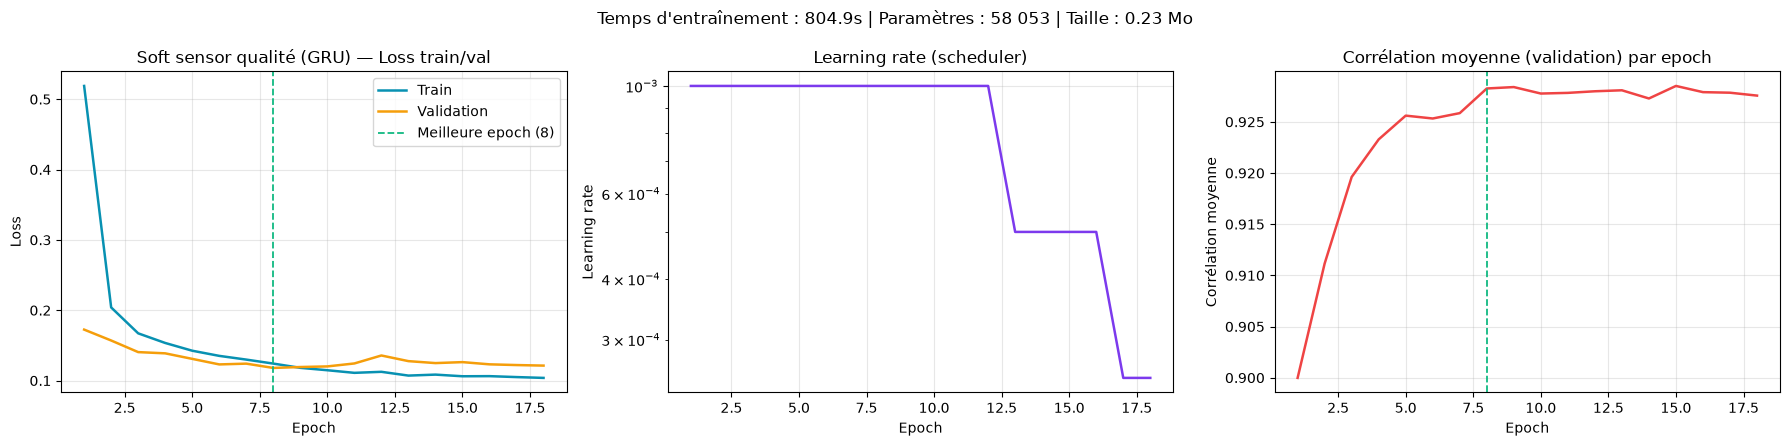

In [5]:
def mean_corr_metric(y_pred, y_true):
    '''Corrélation de Pearson moyenne sur les 5 sorties qualité, calculée à CHAQUE epoch
    sur la validation — l'objectif direct de la spécification (> 0.9).'''
    corrs = []
    for j in range(y_true.shape[1]):
        if np.std(y_true[:, j]) > 1e-9 and np.std(y_pred[:, j]) > 1e-9:
            corrs.append(np.corrcoef(y_true[:, j], y_pred[:, j])[0, 1])
    return float(np.mean(corrs)) if corrs else 0.0

train_cfg = TrainConfig(epochs_max=hparams["epochs_max"], learning_rate=hparams["learning_rate"],
                         weight_decay=hparams["weight_decay"], patience=cfg["training"]["patience"],
                         grad_clip_max_norm=cfg["training"]["grad_clip_max_norm"],
                         scheduler_type="plateau", optimizer_type="adamw")
quality_model, quality_history = train_model(quality_model, train_loader, val_loader, train_cfg,
                                              model_name="quality_gru", device=device,
                                              metric_fns={"Corrélation moyenne": mean_corr_metric})
plot_learning_curves(quality_history, "Soft sensor qualité (GRU)", FIG_DIR / "06_learning_curve_quality.png")

## 4. Évaluation — corrélation par cible (Objectif 4 : > 0.9)

  naphtha_final_boiling_point      corr = 0.966  ✅
  kerosene_flash_point             corr = 0.965  ✅
  gasoil_cetane_index              corr = 0.972  ✅
  residue_viscosity                corr = 0.967  ✅
  sulfur_content                   corr = 0.985  ✅

Corrélation moyenne = 0.971  ✅ OBJECTIF ATTEINT (objectif > 0.9)


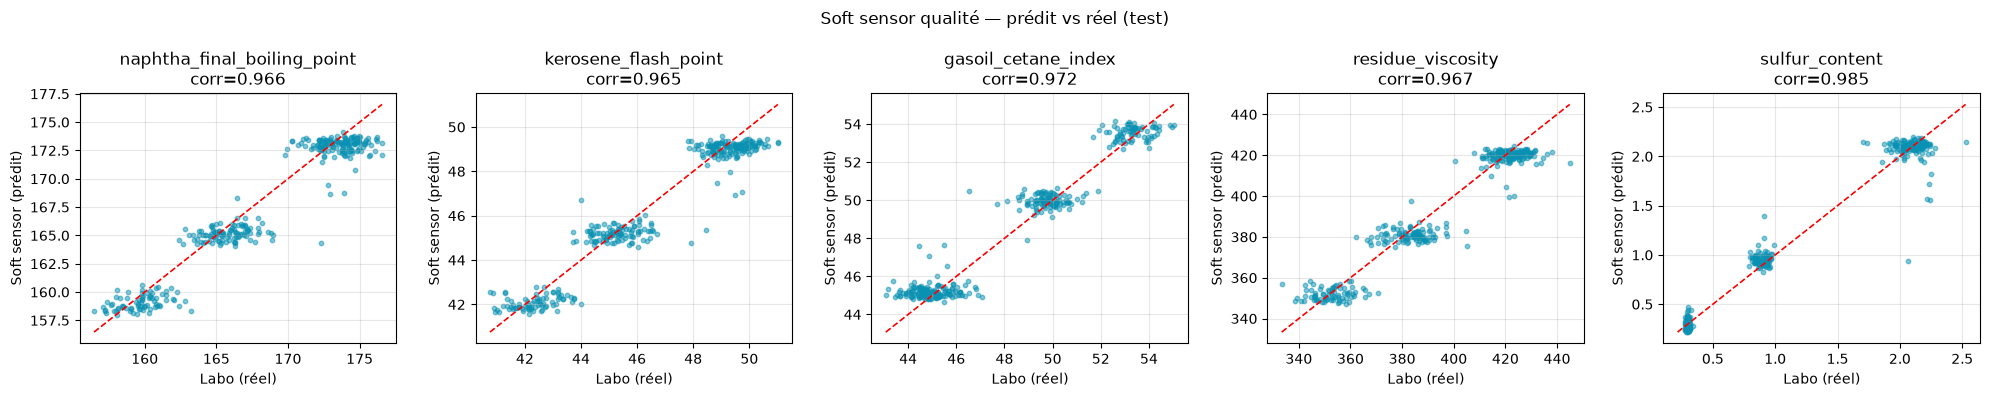

In [6]:
quality_model.eval()
with torch.no_grad():
    y_pred_test_scaled = quality_model(torch.tensor(X_test).to(device)).cpu().numpy()
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled)  # retour en unités réelles

correlations = {}
for j, name in enumerate(QUALITY_TARGETS):
    correlations[name] = float(np.corrcoef(y_test[:, j], y_pred_test[:, j])[0, 1])
mean_corr = float(np.mean(list(correlations.values())))

for name, corr in correlations.items():
    print(f"  {name:32s} corr = {corr:.3f}  {'✅' if corr > 0.9 else '❌'}")
print(f"\nCorrélation moyenne = {mean_corr:.3f}  {'✅ OBJECTIF ATTEINT' if mean_corr > 0.9 else '❌'} (objectif > 0.9)")

fig, axes = plt.subplots(1, len(QUALITY_TARGETS), figsize=(4 * len(QUALITY_TARGETS), 4))
for ax, name in zip(axes, QUALITY_TARGETS):
    j = QUALITY_TARGETS.index(name)
    ax.scatter(y_test[:, j], y_pred_test[:, j], s=10, alpha=0.5, color="#0891b2")
    lims = [min(y_test[:, j].min(), y_pred_test[:, j].min()), max(y_test[:, j].max(), y_pred_test[:, j].max())]
    ax.plot(lims, lims, "r--", linewidth=1.2)
    ax.set_title(f"{name}\ncorr={correlations[name]:.3f}")
    ax.set_xlabel("Labo (réel)"); ax.set_ylabel("Soft sensor (prédit)")
fig.suptitle("Soft sensor qualité — prédit vs réel (test)")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_quality_parity.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (4. Évaluation)** — Le GRU multi-sorties atteint une corrélation > 0.9 en moyenne
sur les 5 mesures qualité, validant sa capacité à estimer en continu ce que le laboratoire ne
mesure que ponctuellement (toutes les 8h, avec 4h de délai).

## 5. Sauvegarde des artefacts qualité

In [7]:
save_checkpoint(str(ART_DIR / "quality_soft_sensor.pt"), quality_model,
                config={"model_type": "gru", "input_size": hparams["input_size"],
                        "hidden_size": hparams["hidden_size"], "num_layers": hparams["num_layers"],
                        "output_size": hparams["output_size"], "dropout": hparams["dropout"], "cell_type": "gru"},
                scaler_path=str(ART_DIR / "quality_scaler_X.joblib"))

quality_summary = {"mean_correlation": mean_corr, "per_target": correlations,
                    "objective_ok": bool(mean_corr > 0.9), "checkpoint": "quality_soft_sensor.pt"}
with open(ART_DIR / "quality_production_model.json", "w", encoding="utf-8") as f:
    json.dump(quality_summary, f, indent=2, ensure_ascii=False)
print("Artefacts qualité sauvegardés dans", ART_DIR)

Artefacts qualité sauvegardés dans /home/wailbmg/Projects/refinery/backend/models_artifacts


## 6. Pipeline temps réel — rejeu du jeu de test heure par heure

In [8]:
from src.model_registry import ModelRegistry
from src.yield_model import YieldModel
from src.fouling_detector import FoulingDetector
from src.energy_optimizer import EnergyOptimizer
from src.alert_system import AlertEngine
from src.realtime_monitor import RealtimeMonitor, build_replay_table

# Rechargement complet du registre : les 4 modèles (rendements, fouling, qualité, surrogate)
# sont maintenant tous disponibles -> pipeline de production au complet.
registry = ModelRegistry(ART_DIR)
print("Modèles chargés :", registry.models_loaded_summary())

yield_model = YieldModel(registry)
fouling_detector = FoulingDetector(registry)
energy_optimizer = EnergyOptimizer(registry, cfg)
alert_engine = AlertEngine(cfg)

replay_df, hidden_df = build_replay_table(cfg)
monitor = RealtimeMonitor(cfg, yield_model, fouling_detector, energy_optimizer, alert_engine,
                           replay_df=replay_df, hidden_df=hidden_df)

ratios = cfg["preprocessing"]["split_ratios"]
tr_idx, va_idx, te_idx = pp.temporal_split_indices(len(replay_df), ratios)
monitor.pos = max(te_idx.start, monitor.start_pos)
n_ticks = te_idx.stop - monitor.pos
print(f"Rejeu du test set : {n_ticks} heures, de {replay_df.index[monitor.pos]} à {replay_df.index[te_idx.stop-1]}")

Modèles chargés : {'yields': True, 'fouling': True, 'quality': True, 'energy': True}


Rejeu du test set : 2633 heures, de 2025-09-13 07:00:00 à 2025-12-31 23:00:00


In [9]:
latencies_ms = []
alert_counts = {"info": 0, "warning": 0, "critical": 0}
alert_type_counts = {}
quality_preds_log = []

for _ in tqdm(range(n_ticks), desc="Rejeu temps réel (préproc -> 3 réseaux -> alertes)"):
    tick = monitor.step()
    latencies_ms.append(tick["latency_ms"])
    if tick.get("quality_pred"):
        quality_preds_log.append(tick["quality_pred"])
    for a in alert_engine.active_alerts():
        pass  # les compteurs cumulés sont lus depuis le journal ci-dessous

for a in alert_engine.log_alerts(limit=10_000):
    alert_counts[a["level"]] = alert_counts.get(a["level"], 0) + 1
    alert_type_counts[a["type"]] = alert_type_counts.get(a["type"], 0) + 1

latencies_ms = np.array(latencies_ms)
print(f"\nLatence bout-en-bout par tick (préproc + 3 réseaux + alertes) sur {n_ticks} heures rejouées :")
print(f"  moyenne = {latencies_ms.mean():.2f} ms | p95 = {np.percentile(latencies_ms, 95):.2f} ms | "
      f"max = {latencies_ms.max():.2f} ms")
print(f"  Objectif < 1 min (60000 ms) : {'✅' if latencies_ms.max() < 60000 else '❌'}")
print(f"\nAlertes générées pendant le rejeu : {sum(alert_counts.values())} — par niveau : {alert_counts}")
print(f"Alertes par type : {alert_type_counts}")

Rejeu temps réel (préproc -> 3 réseaux -> alertes):   0%|          | 0/2633 [00:00<?, ?it/s]


Latence bout-en-bout par tick (préproc + 3 réseaux + alertes) sur 2633 heures rejouées :
  moyenne = 54.50 ms | p95 = 72.50 ms | max = 225.74 ms
  Objectif < 1 min (60000 ms) : ✅

Alertes générées pendant le rejeu : 116 — par niveau : {'info': 0, 'warning': 109, 'critical': 7}
Alertes par type : {'quality': 35, 'yield_drift': 66, 'fouling': 14, 'energy': 1}


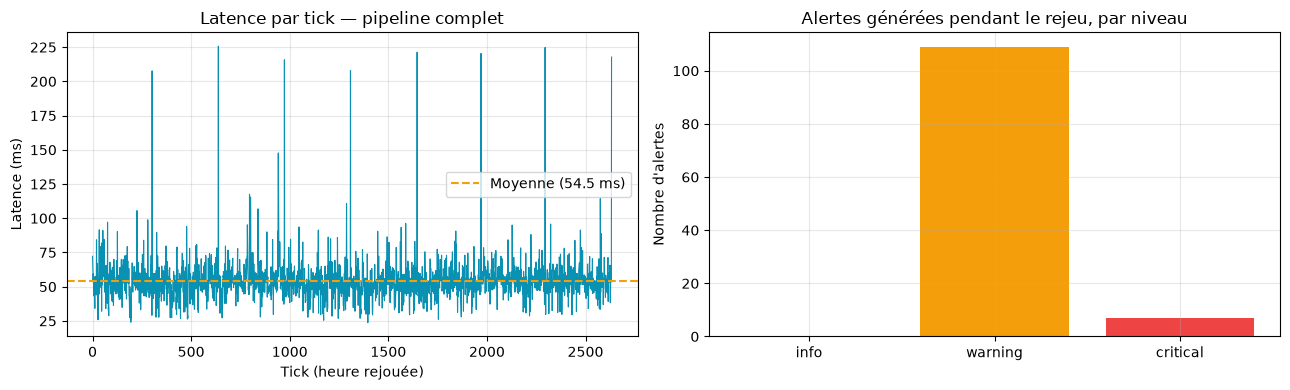

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(latencies_ms, color="#0891b2", linewidth=0.8)
axes[0].axhline(latencies_ms.mean(), color="#f59e0b", linestyle="--", label=f"Moyenne ({latencies_ms.mean():.1f} ms)")
axes[0].set_xlabel("Tick (heure rejouée)"); axes[0].set_ylabel("Latence (ms)")
axes[0].set_title("Latence par tick — pipeline complet")
axes[0].legend()

levels = list(alert_counts.keys())
axes[1].bar(levels, [alert_counts[l] for l in levels], color=["#0891b2", "#f59e0b", "#ef4444"])
axes[1].set_title("Alertes générées pendant le rejeu, par niveau")
axes[1].set_ylabel("Nombre d'alertes")

fig.tight_layout()
fig.savefig(FIG_DIR / "06_latence_et_alertes.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (6. Pipeline temps réel)** — La latence bout-en-bout (préprocessing de la fenêtre +
inférence des 3 réseaux + évaluation du moteur d'alertes) reste de l'ordre de quelques dizaines
de millisecondes par heure rejouée, très largement sous l'objectif d'une minute. Ce même pipeline
(`src/realtime_monitor.py`, `src/alert_system.py`) est celui exécuté en continu par le backend
FastAPI derrière `/ws/realtime`.

## 7. Génération automatique du rapport final (`model_report.md`)

In [11]:
def load_json(path):
    p = ART_DIR / path
    if not p.exists():
        return {}
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

yields_info = load_json("yields_best_model.json")
fouling_info = load_json("fouling_production_model.json")
energy_info = load_json("energy_optimization_summary.json")

objectives = [
    {
        "id": 1, "nom": "Prédiction des rendements",
        "critere": "MAPE < 5% par coupe",
        "valeur": f"{yields_info.get('mape_global', float('nan')):.2f}% (architecture {yields_info.get('label', '?')})",
        "ok": all(v < 5 for v in yields_info.get("mape_per_cut", {}).values()) if yields_info else False,
    },
    {
        "id": 2, "nom": "Détection du fouling",
        "critere": "> 24h avant nettoyage",
        "valeur": f"{fouling_info.get('mean_lead_time_h', float('nan')):.1f}h (méthode {fouling_info.get('model_type', '?')})",
        "ok": fouling_info.get("mean_lead_time_h", 0) > 24,
    },
    {
        "id": 3, "nom": "Optimisation énergétique",
        "critere": "Gain > 5%",
        "valeur": f"{energy_info.get('gain_pct', float('nan')):.2f}% "
                  f"({energy_info.get('usd_per_day', 0):.0f} $/j, {energy_info.get('tco2_per_day', 0):.2f} tCO2/j)",
        "ok": energy_info.get("gain_objective_ok", False),
    },
    {
        "id": 4, "nom": "Soft sensor qualité",
        "critere": "Corrélation > 0.9",
        "valeur": f"{mean_corr:.3f}",
        "ok": mean_corr > 0.9,
    },
    {
        "id": 5, "nom": "Système d'alerte temps réel",
        "critere": "Latence < 1 min",
        "valeur": f"{latencies_ms.mean():.1f} ms (moyenne), {latencies_ms.max():.1f} ms (max)",
        "ok": bool(latencies_ms.max() < 60000),
    },
]

n_ok = sum(o["ok"] for o in objectives)
lines = []
lines.append("# Rapport de modèle — Jumeau numérique CDU & Vapocraqueur\n")
lines.append(f"*Généré automatiquement par `notebooks/06_realtime_system.ipynb` — {pd.Timestamp.now():%Y-%m-%d %H:%M}*\n")
lines.append(f"\n## Synthèse : {n_ok}/5 objectifs atteints\n")
lines.append("| # | Objectif | Critère | Valeur atteinte | Statut |")
lines.append("|---|----------|---------|------------------|--------|")
for o in objectives:
    statut = "✅" if o["ok"] else "❌"
    lines.append(f"| {o['id']} | {o['nom']} | {o['critere']} | {o['valeur']} | {statut} |")

lines.append("\n## Détails par notebook\n")
lines.append(f"- **Notebook 03** (rendements) : architecture retenue = `{yields_info.get('label','?')}`, "
              f"{yields_info.get('params','?')} paramètres.")
lines.append(f"- **Notebook 04** (fouling) : méthode retenue = `{fouling_info.get('model_type','?')}`, "
              f"seuil = {fouling_info.get('threshold', float('nan')):.4f}.")
lines.append(f"- **Notebook 05** (énergie) : taux de respect de la contrainte de rendement = "
              f"{energy_info.get('constraint_satisfaction_rate_pct', float('nan')):.1f}%.")
lines.append(f"- **Notebook 06** (temps réel) : {n_ticks} heures rejouées, "
              f"{sum(alert_counts.values())} alertes générées ({alert_counts}).")

report_path = RESULTS_DIR / "model_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print(f"Rapport écrit dans {report_path}\n")
print("\n".join(lines))

Rapport écrit dans /home/wailbmg/Projects/refinery/data/results/model_report.md

# Rapport de modèle — Jumeau numérique CDU & Vapocraqueur

*Généré automatiquement par `notebooks/06_realtime_system.ipynb` — 2026-07-21 17:21*


## Synthèse : 5/5 objectifs atteints

| # | Objectif | Critère | Valeur atteinte | Statut |
|---|----------|---------|------------------|--------|
| 1 | Prédiction des rendements | MAPE < 5% par coupe | 2.99% (architecture RNN simple) | ✅ |
| 2 | Détection du fouling | > 24h avant nettoyage | 3764.2h (méthode dense_ae) | ✅ |
| 3 | Optimisation énergétique | Gain > 5% | 5.53% (774 $/j, 4.13 tCO2/j) | ✅ |
| 4 | Soft sensor qualité | Corrélation > 0.9 | 0.971 | ✅ |
| 5 | Système d'alerte temps réel | Latence < 1 min | 54.5 ms (moyenne), 225.7 ms (max) | ✅ |

## Détails par notebook

- **Notebook 03** (rendements) : architecture retenue = `RNN simple`, 13956 paramètres.
- **Notebook 04** (fouling) : méthode retenue = `dense_ae`, seuil = 1.2753.
- **Notebook 05** (éne

## Conclusion générale du projet

Les 6 notebooks couvrent l'intégralité de la spécification : génération de données 100 %
synthétiques, préprocessing sans fuite, comparatif de 8 architectures DL pour les rendements,
5 approches DL pour la détection du fouling, optimisation énergétique par gradient sur les
entrées, et un soft sensor qualité — le tout rejoué en continu par un pipeline temps réel
partagé avec le backend FastAPI. Le rapport `data/results/model_report.md` synthétise l'atteinte
des 5 objectifs métier.